In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 12.0 MB/s eta 0:00:00


In [2]:
import numpy as np
from sklearn.utils import shuffle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
import time

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Traverse/attack-free-1.csv', delimiter=',')
df['datetime'] = df['timestamp']
df['arbitration_id'] = df['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['data_field'] = df['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['attack'] = 0
df = df.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

dg = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Traverse/force-neutral-1.csv', delimiter=',')
dg['datetime'] = dg['timestamp']
dg['arbitration_id'] = dg['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dg['data_field'] = dg['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dg['attack'] = 1
dg = dg.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

# Feature and label extraction
data = pd.concat([df, dg])
data = shuffle(data)

X = data[['datetime','arbitration_id', 'data_field']]
y = data['attack']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Model: KNN
Best Score: 0.6132173661021186
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 0.5660
Precision: 0.5750
Recall: 0.5340
F1 Score: 0.5537
ROC AUC: 0.7127
Training Time: 11.67 seconds
Prediction Time: 1.05 seconds




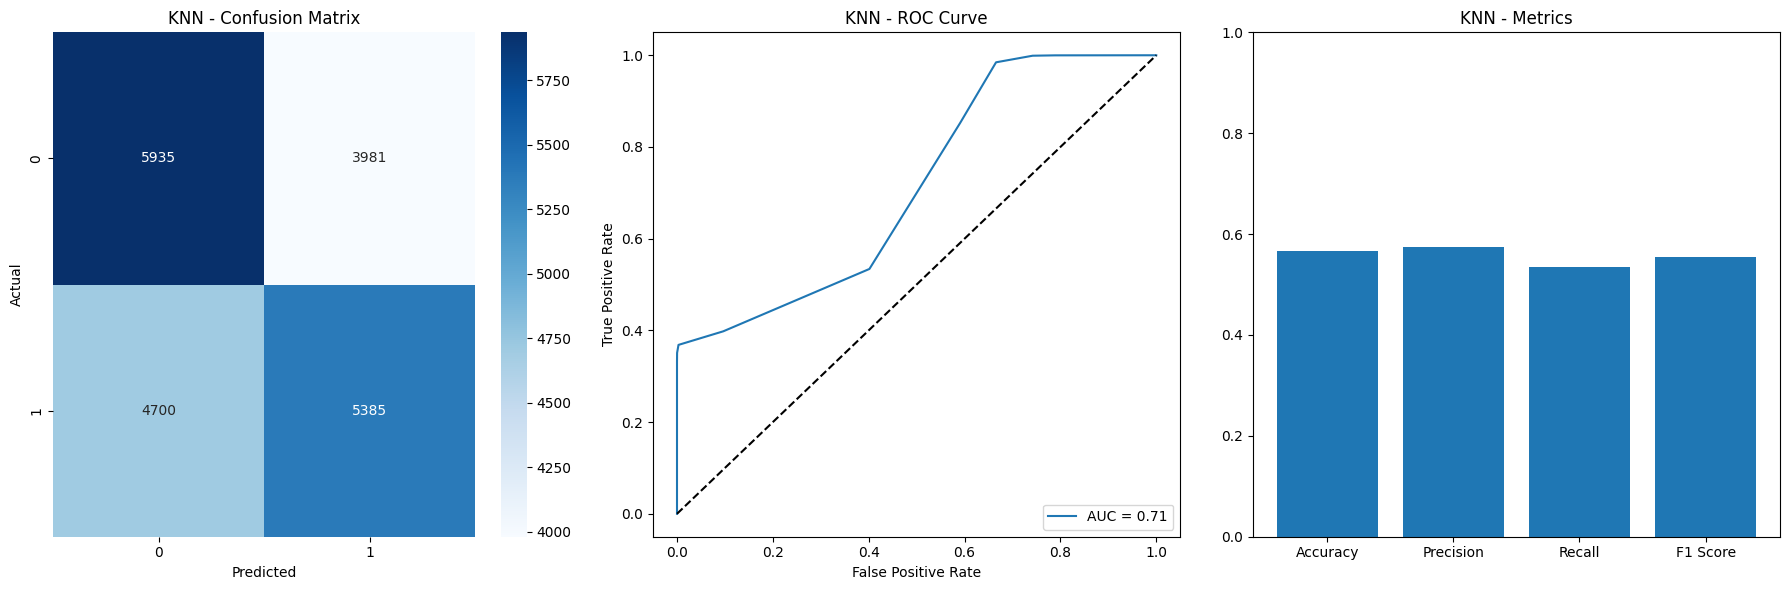

Model: LogisticRegression
Best Score: 0.5489681394912818
Best Params: {'C': 0.01, 'solver': 'liblinear'}
Accuracy: 0.5432
Precision: 0.5943
Recall: 0.2965
F1 Score: 0.3956
ROC AUC: 0.5752
Training Time: 0.73 seconds
Prediction Time: 0.00 seconds




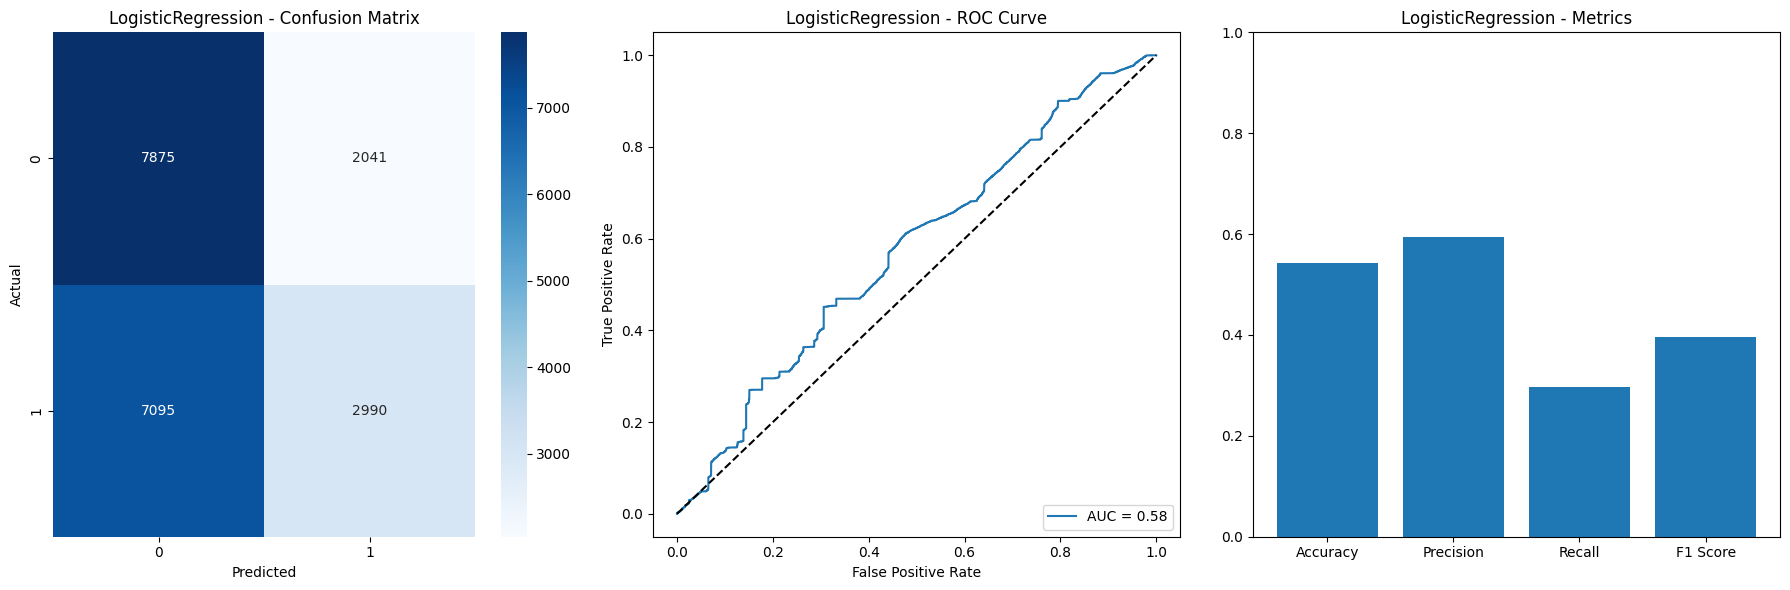

Model: DecisionTree
Best Score: 0.7213284591588025
Best Params: {'criterion': 'gini', 'max_depth': 10}
Accuracy: 0.7245
Precision: 0.7042
Recall: 0.7822
F1 Score: 0.7411
ROC AUC: 0.8494
Training Time: 6.39 seconds
Prediction Time: 0.00 seconds




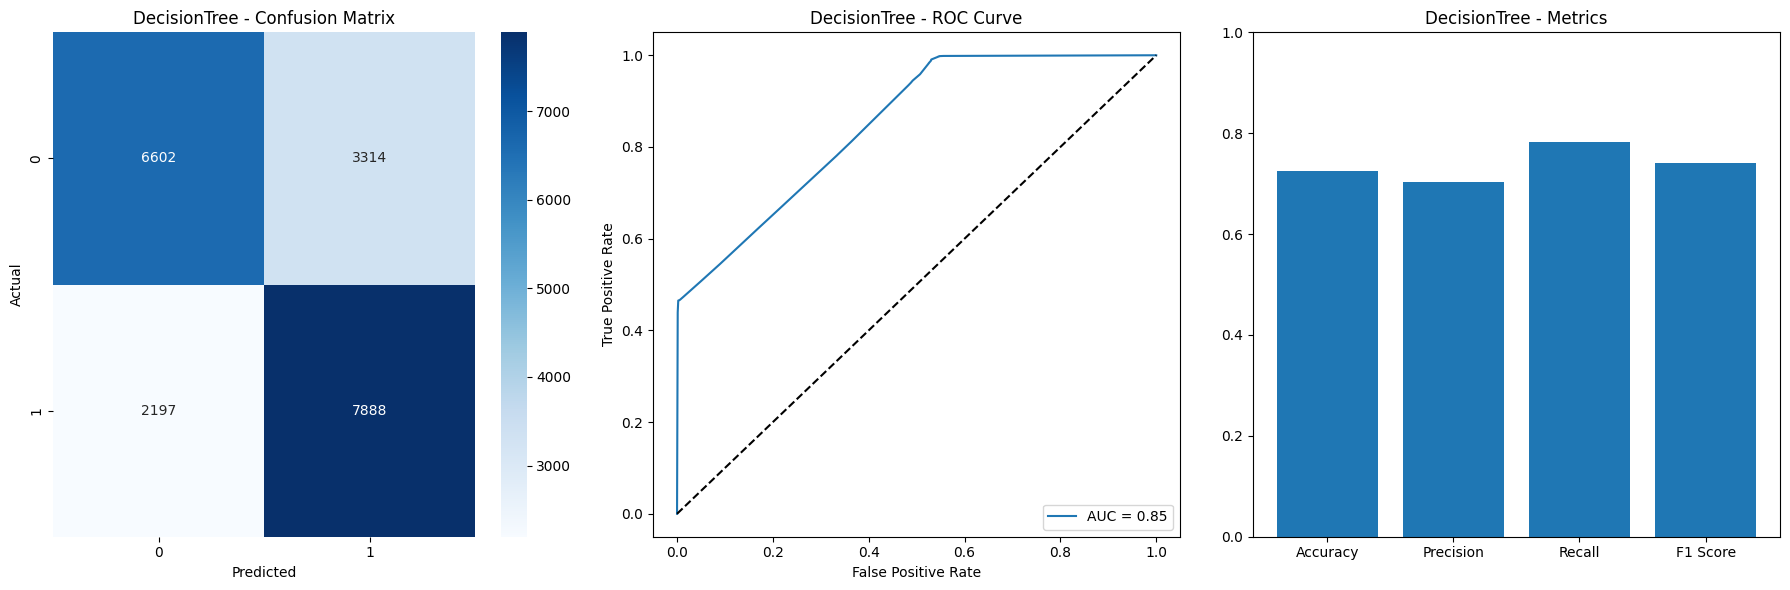

Model: RandomForest
Best Score: 0.727403407599525
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 50}
Accuracy: 0.7298
Precision: 0.8353
Recall: 0.5780
F1 Score: 0.6832
ROC AUC: 0.8444
Training Time: 534.52 seconds
Prediction Time: 0.07 seconds




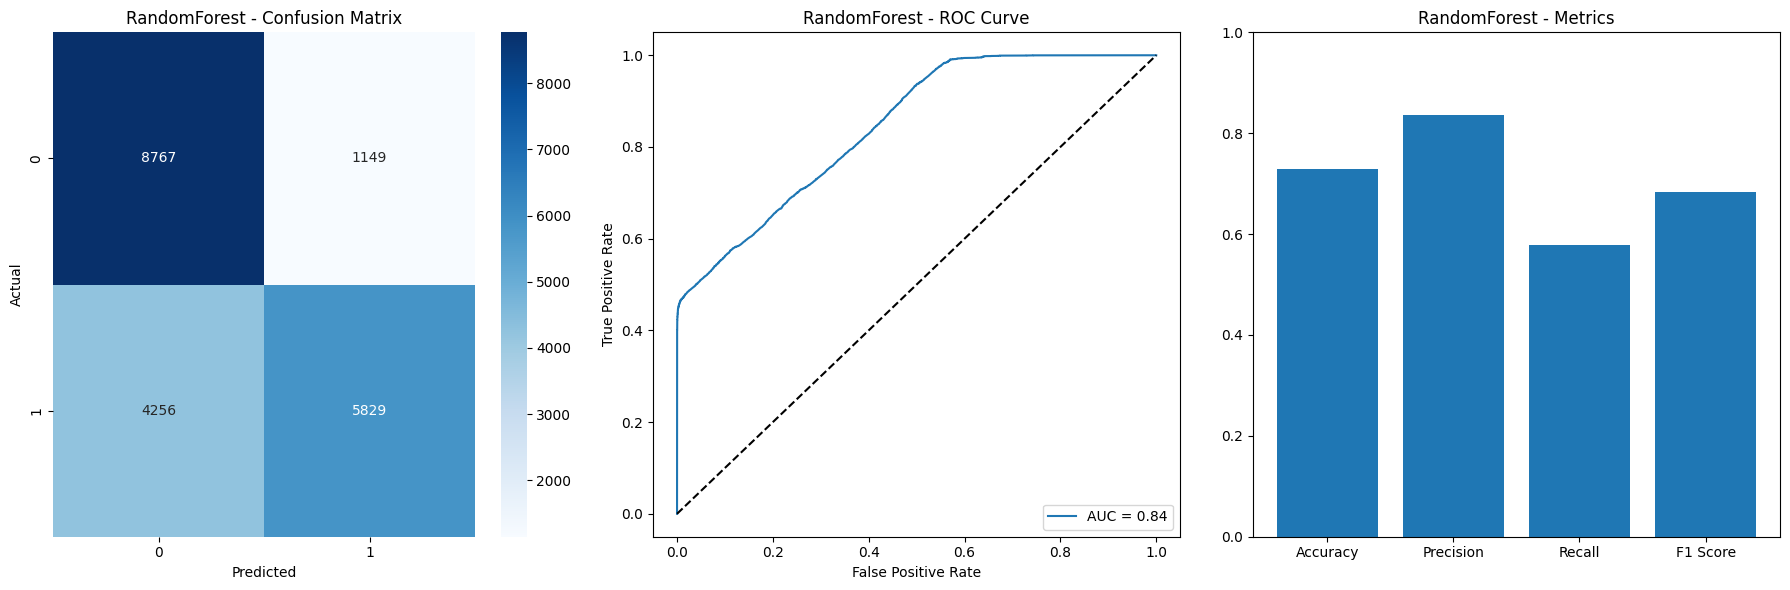

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:41:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost
Best Score: 0.8423519803449784
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.8440
Precision: 0.9187
Recall: 0.7576
F1 Score: 0.8304
ROC AUC: 0.9484
Training Time: 22.50 seconds
Prediction Time: 0.02 seconds




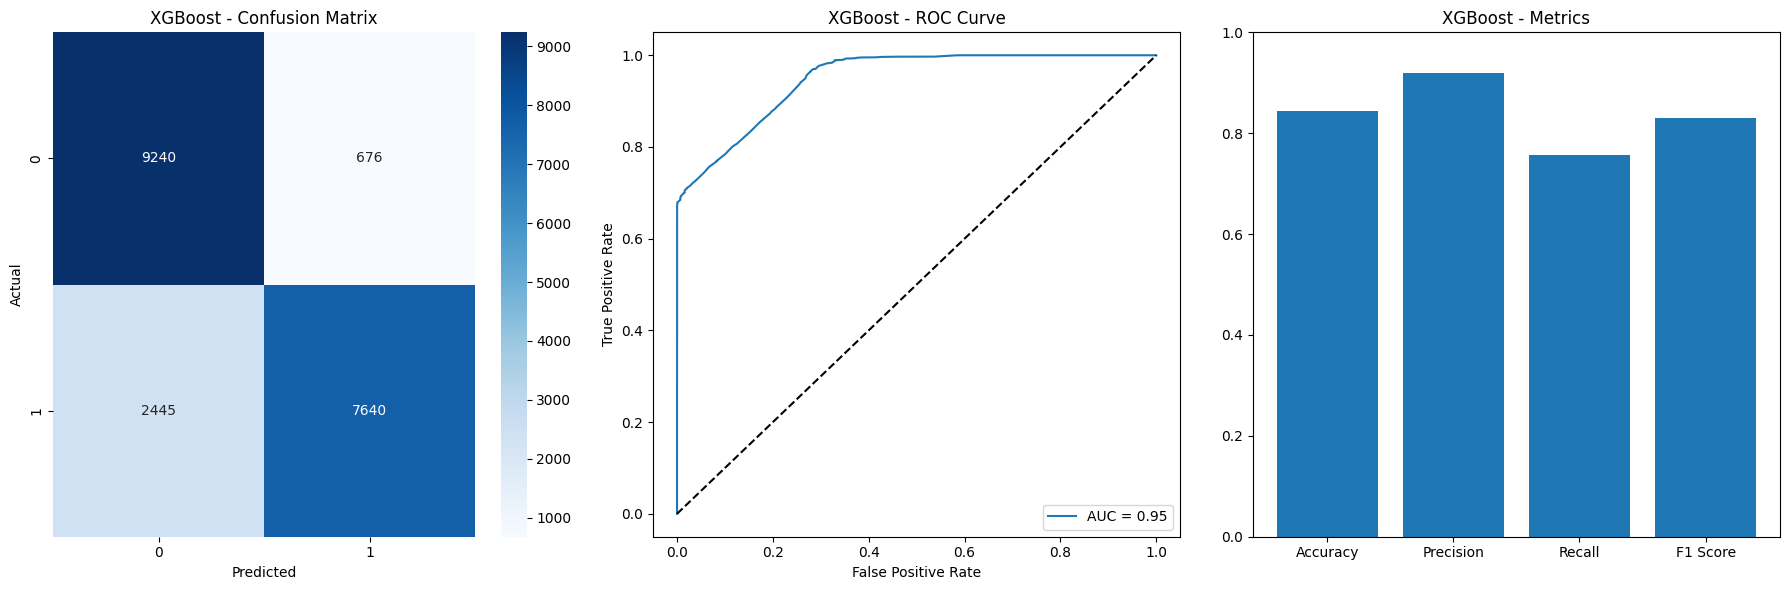

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Model: CatBoost
Best Score: 0.8722391053684145
Best Params: {'depth': 4, 'iterations': 300, 'learning_rate': 0.1}
Accuracy: 0.8725
Precision: 0.9349
Recall: 0.8030
F1 Score: 0.8639
ROC AUC: 0.9670
Training Time: 416.88 seconds
Prediction Time: 0.01 seconds




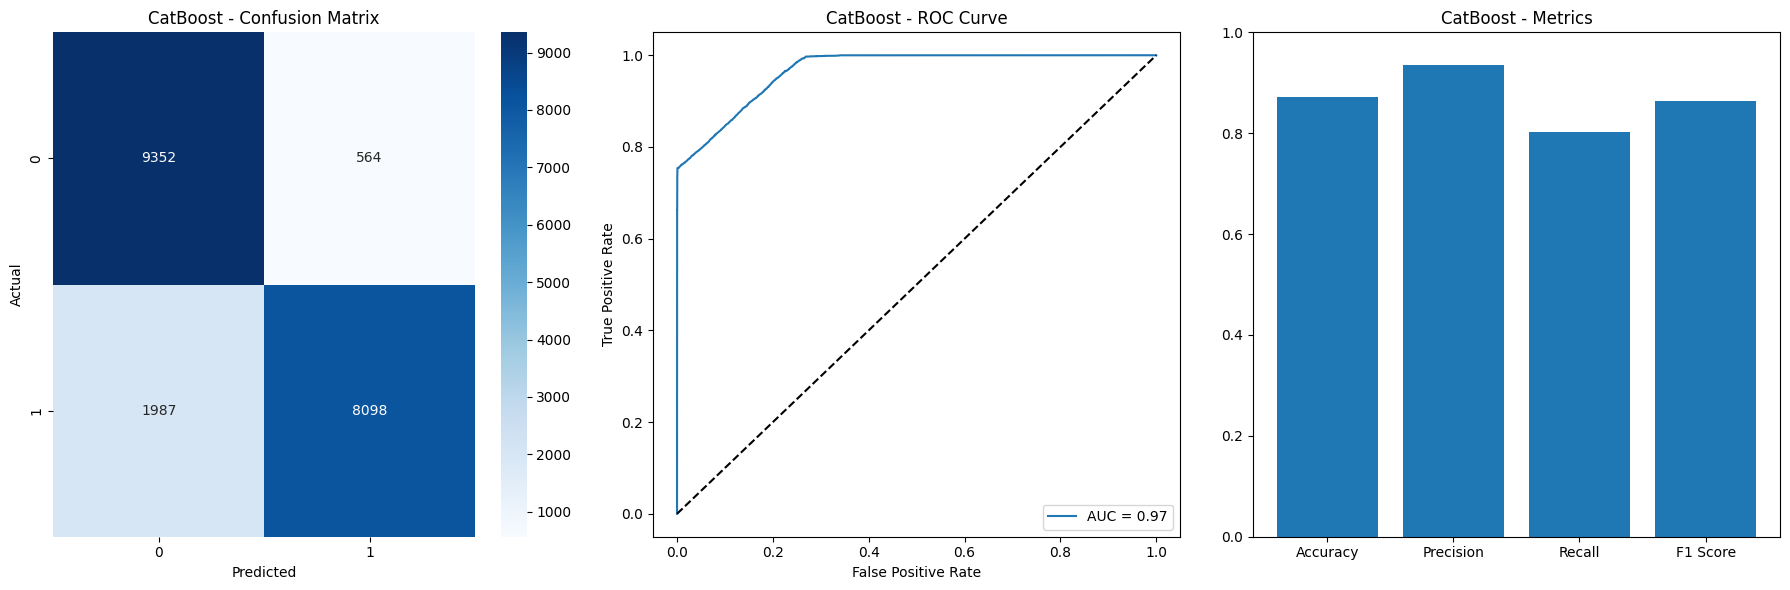

Summary of Results:
Model: KNN
Best Score: 0.6132173661021186
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 0.5660
Precision: 0.5750
Recall: 0.5340
F1 Score: 0.5537
ROC AUC: 0.7127
Training Time: 11.67 seconds
Prediction Time: 1.05 seconds


Model: LogisticRegression
Best Score: 0.5489681394912818
Best Params: {'C': 0.01, 'solver': 'liblinear'}
Accuracy: 0.5432
Precision: 0.5943
Recall: 0.2965
F1 Score: 0.3956
ROC AUC: 0.5752
Training Time: 0.73 seconds
Prediction Time: 0.00 seconds


Model: DecisionTree
Best Score: 0.7213284591588025
Best Params: {'criterion': 'gini', 'max_depth': 10}
Accuracy: 0.7245
Precision: 0.7042
Recall: 0.7822
F1 Score: 0.7411
ROC AUC: 0.8494
Training Time: 6.39 seconds
Prediction Time: 0.00 seconds


Model: RandomForest
Best Score: 0.727403407599525
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 50}
Accuracy: 0.7298
Precision: 0.8353
Recall: 0.5780
F1 Score: 0.6832
ROC AUC: 0.8444
Training Time: 

In [5]:
# Define models and their hyperparameters for GridSearchCV
models = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 10, 20, 30, 40, 50]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [10, 50, 100, 200],
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 10, 20, 30, 40, 50]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7, 9]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(verbose=0),
        'params': {
            'iterations': [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.2],
            'depth': [4, 6, 8]
        }
    }
}

# Perform GridSearchCV with K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for model_name, mp in models.items():
    start_time = time.time()
    clf = GridSearchCV(mp['model'], mp['params'], cv=kf, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    best_model = clf.best_estimator_

    print(f"Model: {model_name}")
    print(f"Best Score: {clf.best_score_}")
    print(f"Best Params: {clf.best_params_}")

    # Predict and calculate metrics
    start_time = time.time()
    y_pred = best_model.predict(X_test_scaled)
    end_time = time.time()
    prediction_time = end_time - start_time
    y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Prediction Time: {prediction_time:.2f} seconds")
    print("\n")

    # Plot confusion matrix and ROC curve
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
    ax[0].set_title(f'{model_name} - Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f'{model_name} - ROC Curve')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc='lower right')

    # Bar plot for metrics
    metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
    ax[2].bar(metrics.keys(), metrics.values())
    ax[2].set_ylim(0, 1)
    ax[2].set_title(f'{model_name} - Metrics')

    plt.tight_layout()
    plt.show()

    results[model_name] = {
        'best_score': clf.best_score_,
        'best_params': clf.best_params_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'training_time': training_time,
        'prediction_time': prediction_time
    }

# Print summary of results
print("Summary of Results:")
for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Best Score: {result['best_score']}")
    print(f"Best Params: {result['best_params']}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall: {result['recall']:.4f}")
    print(f"F1 Score: {result['f1_score']:.4f}")
    print(f"ROC AUC: {result['roc_auc']:.4f}")
    print(f"Training Time: {result['training_time']:.2f} seconds")
    print(f"Prediction Time: {result['prediction_time']:.2f} seconds")
    print("\n")

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:48:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:49:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:49:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Stacked Model Results:
Accuracy: 0.9692
Precision: 0.9691
Recall: 0.9698
F1 Score: 0.9694
ROC AUC: 0.9954
Training Time: 64.41 seconds
Prediction Time: 0.43 seconds


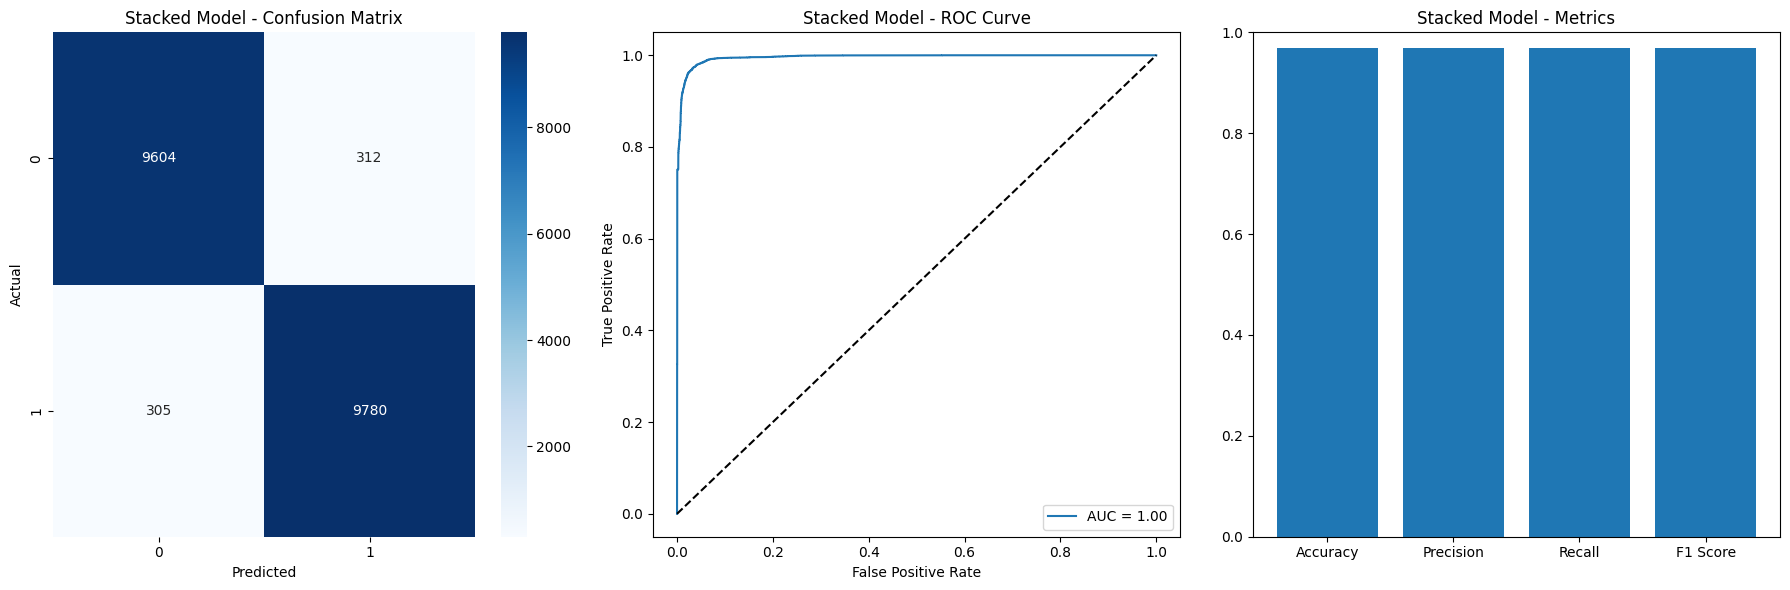

In [6]:
# Define base models
base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')),
    #('logistic', LogisticRegression(C=1, solver='liblinear', max_iter=1000)),
    ('decision_tree', DecisionTreeClassifier(criterion='gini', max_depth=20)),
    ('random_forest', RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=20)),
    ('xgboost', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')),
    ('catboost', CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0))
]

# Define meta-learner
meta_learner = LogisticRegression()

# Define stacking classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

# Train stacking model
start_time = time.time()
stacked_model.fit(X_train_scaled, y_train)
end_time = time.time()
training_time = end_time - start_time

# Predict and calculate metrics
start_time = time.time()
y_pred = stacked_model.predict(X_test_scaled)
end_time = time.time()
prediction_time = end_time - start_time
y_pred_prob = stacked_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Stacked Model Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")

# Plot confusion matrix and ROC curve
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Stacked Model - Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Stacked Model - ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right')

# Bar plot for metrics
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
ax[2].bar(metrics.keys(), metrics.values())
ax[2].set_ylim(0, 1)
ax[2].set_title('Stacked Model - Metrics')

plt.tight_layout()
plt.show()
